In [1]:
%pip install -U transformers datasets peft accelerate bitsandbytes

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import json
import time
from pathlib import Path
from collections import defaultdict, Counter
from typing import Dict, List, Tuple
import ast
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from difflib import SequenceMatcher
import re
import pandas as pd
import numpy as np
from tqdm import tqdm

In [3]:
# !git clone https://github.com/DimitrisKu/Active-Reading--Pattern-Recognition.git

# import os

# # %cd /kaggle/working/Active-Reading--Pattern-Recognition

# %cd /content/Active-Reading--Pattern-Recognition # if in Colab

# os.getcwd()

## Load the SimpleQA Dataset

In [4]:
import json

def alnum_key(s: str) -> str:
    return "".join(ch.lower() for ch in (s or "") if ch.isalnum())

names_path = "filtered_doc_names_sw.json"

with open(names_path, "r", encoding="utf-8") as f:
    target_names = json.load(f)

target_keys = {alnum_key(n) for n in target_names}
print("target_keys:", len(target_keys))  # should be 856

target_keys: 856


In [5]:
import ast
from urllib.parse import urlparse, unquote

WIKI_HOSTS = {"en.wikipedia.org"}
WIKI_PREFIX = "/wiki/"

def parse_metadata(meta_str: str) -> dict:
    """metadata is stored as a string; parse into a dict safely."""
    if not meta_str:
        return {}
    try:
        # Many rows look like "{'topic':..., 'urls':[...]}": python-literal style
        return ast.literal_eval(meta_str)
    except Exception:
        # fallback: return empty
        return {}

def extract_wikipedia_title(url: str) -> str | None:
    """Return decoded Wikipedia page title (string after /wiki/), or None."""
    if not url:
        return None
    try:
        u = urlparse(url)
    except Exception:
        return None

    if u.netloc not in WIKI_HOSTS:
        return None
    if not u.path.startswith(WIKI_PREFIX):
        return None

    title = u.path[len(WIKI_PREFIX):]  # the part after /wiki/
    title = unquote(title)
    title = title.split("#", 1)[0].split("?", 1)[0]
    title = title.replace("_", " ").strip()
    return title if title else None

def filter_urls_to_target_wikipedia(urls: list[str], target_keys: set[str]) -> list[str]:
    """Keep only Wikipedia URLs whose titles match target_keys alphanumerically."""
    kept = []
    for url in urls or []:
        title = extract_wikipedia_title(url)
        if title and alnum_key(title) in target_keys:
            kept.append(url)
    return kept


In [6]:
from datasets import load_dataset

print("Loading SimpleQA...")
ds = load_dataset("basicv8vc/SimpleQA")
test = ds["test"]

def row_matches(example):
    meta = parse_metadata(example.get("metadata", ""))
    urls = meta.get("urls", [])
    kept_wiki = filter_urls_to_target_wikipedia(urls, target_keys)
    return len(kept_wiki) > 0

filtered = test.filter(row_matches)

print("Original test rows:", len(test))
print("Filtered rows:", len(filtered))

Loading SimpleQA...
Original test rows: 4326
Filtered rows: 1252


In [7]:
SEED = 42
N_SAMPLES = 100

filtered_100 = filtered.shuffle(seed=SEED).select(range(N_SAMPLES))

print("Final evaluation set size:", len(filtered_100))

Final evaluation set size: 100


In [8]:
# # In your notebook, run this to get the source URL for any question:
# from datasets import load_dataset
# import ast

# ds = load_dataset("basicv8vc/SimpleQA")
# test = ds["test"]

# # Find the Timoshenko question
# for i, row in enumerate(test):
#     if "Timoshenko" in row.get("problem", ""):
#         meta = ast.literal_eval(row.get("metadata", "{}"))
#         print(f"Question: {row['problem']}")
#         print(f"Answer: {row['answer']}")
#         print(f"URLs: {meta.get('urls', [])}")
#         break

Question: In what year did Stepan Prokopovich Timoshenko receive the Worcester Reed Warner Medal?
Answer: 1935
URLs: ['https://en.wikipedia.org/wiki/Worcester_Reed_Warner#Worcester_Reed_Warner_Medal', 'https://www.asme.org/about-asme/honors-awards/literature-awards/worcester-reed-warner-medal', 'https://en.wikipedia.org/wiki/Worcester_Reed_Warner', 'https://watermark.silverchair.com/493_1.pdf?token=AQECAHi208BE49Ooan9kkhW_Ercy7Dm3ZL_9Cf3qfKAc485ysgAABGAwggRcBgkqhkiG9w0BBwagggRNMIIESQIBADCCBEIGCSqGSIb3DQEHATAeBglghkgBZQMEAS4wEQQMvegxpaLqdbE_YqFiAgEQgIIEExwkQFNwsKOV8IWn1_Ph1kRUgo9CDJYdKtVmb2O86ntfitIs5dZkJas0rBsVfBxYAOSe5jWXvAquk-zndamvgLUp4zyHdfAbqc5dVvgziFkrmVyQyDPQygh609I8Gsjg6jWTP-3RChfRP0yDcmJMMMqSvxpKNNSwHPi-kMFVDVMgF0efOowaHBXtpoNTMz0tRna4gQDIOvs6jKlX-L025zNTtQ7yGRy8aTPT7P-MvTWTVq7hr3Nuv4o9gcc7e0dLwmDWScm6MLWRQ6BBdpkNPOJLMmL_0gvHE4NaOjbGsY7ClreUmW_414sXIvIueWC3-eH9RSSzWK57BGnG9qYUftRNWe5lDXVBetwLNBe0Hk4pdj4OWHyhl7KLs_NPcxKf4j2Vb_9VRsNtH_dcPcVGNwAD8NTEnSIDQZuYXezus8NXDplNhAUKaVUoGs

## Model Loading

In [9]:
import json

repetition_dataset_path = "/Users/christos/Desktop/Active-Reading--Pattern-Recognition/Finetune_Datasets/simplewiki/repetition_dataset.jsonl"

doc_lookup = {}

with open(repetition_dataset_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        obj = json.loads(line)
        doc_name = obj.get("doc_name")
        text = obj.get("text")
        if doc_name and text:
            doc_lookup[alnum_key(doc_name)] = {
                "doc_name": doc_name,
                "text": text
            }

print(f"Loaded {len(doc_lookup)} documents from repetition dataset")

Loaded 856 documents from repetition dataset


In [10]:
# Enrich each question with its source document and text
enriched_data = []

for example in filtered_100:
    meta = parse_metadata(example.get("metadata", ""))
    urls = meta.get("urls", [])
    kept_wiki = filter_urls_to_target_wikipedia(urls, target_keys)
    
    # Extract document name from kept Wikipedia URLs
    matched_docs = []
    seen_docs = set()
    for url in kept_wiki:
        title = extract_wikipedia_title(url)
        if title and alnum_key(title) in doc_lookup:
            doc_info = doc_lookup[alnum_key(title)]
            doc_name = doc_info["doc_name"]
            # Only add if we haven't seen this doc name before
            if doc_name not in seen_docs:
                matched_docs.append(doc_info)
                seen_docs.add(doc_name)
    
    enriched_data.append({
        "question": example.get("problem"),
        "answer": example.get("answer"),
        "metadata": meta,
        "matched_docs": matched_docs,
        "matched_doc_names": [doc["doc_name"] for doc in matched_docs]
    })

print(f"Enriched {len(enriched_data)} questions with source documents")
print(f"Sample question with matched docs:")
if enriched_data:
    # Find first non-empty question
    for sample in enriched_data:
        if sample['question'] and sample['matched_docs']:
            question_preview = sample['question'][:100] + "..." if len(sample['question']) > 100 else sample['question']
            print(f"  Question: {question_preview}")
            print(f"  Matched docs: {sample['matched_doc_names']}")
            break
    else:
        print("  No questions with matched documents found")


Enriched 100 questions with source documents
Sample question with matched docs:
  Question: In which year did William Hammon at the University of Pittsburgh purify the gamma globulin component...
  Matched docs: ['Polio']


In [11]:
# Question -> Document Mapping with helper function

def view_qa_with_source(idx):
    """Display question, answer, and full source document text"""
    if idx >= len(enriched_data):
        print(f"Index out of range. Max: {len(enriched_data)-1}")
        return
    
    item = enriched_data[idx]
    print(f"{'='*80}")
    print(f"Question #{idx}:")
    print(f"{item['question'] or '(None)'}\n")
    print(f"Answer: {item['answer'] or '(None)'}\n")
    print(f"Matched Documents ({len(item['matched_doc_names'])}):")
    
    if item['matched_docs']:
        for doc in item['matched_docs']:
            print(f"\n--- {doc['doc_name']} ---")
            text_preview = doc['text'][:500] + "..." if len(doc['text']) > 500 else doc['text']
            print(text_preview)
    else:
        print("(No matched documents)")
    print(f"{'='*80}\n")

# Display mapping
print("Question -> Document Mapping\n")
print("="*100)

for idx, item in enumerate(enriched_data):
    question = item['question'] or "(No question text)"
    doc_names = item['matched_doc_names']
    question_preview = question[:85] + "..." if len(question) > 85 else question
    
    print(f"\n[{idx}] {question_preview}")
    print(f"     -> {doc_names}")

print(f"\n{'='*100}")
print(f"\nTotal: {len(enriched_data)} questions")
matched_count = sum(1 for item in enriched_data if item['matched_doc_names'])
print(f"With matches: {matched_count}")
print(f"Without matches: {len(enriched_data) - matched_count}")

# Example: view_qa_with_source(0)  # Uncomment to view full details of question 0


Question -> Document Mapping


[0] In which year did William Hammon at the University of Pittsburgh purify the gamma glo...
     -> ['Polio']

[1] How many innings did Javier López pitch in the '07 World Series?
     -> ['2007 World Series']

[2] Which football team won the first and only ELFA Challenge Cup competition in 1922?
     -> ['English Ladies Football Association']

[3] In what year did Stepan Prokopovich Timoshenko receive the Worcester Reed Warner Meda...
     -> ['Worcester Reed Warner']

[4] In One on One, Season 1, Episode 5, titled "My Life as a Dog," what celebrity made a ...
     -> ['One on One (American TV series)']

[5] In which month and year did the Washington Post (an American daily newspaper) hire Ra...
     -> ['Rana Ayyub']

[6] How old was Clint Ballard Jr. when he first played the piano for KTSM, an El Paso rad...
     -> ['Clint Ballard Jr.']

[7] The K-class blimp (1938), the K-14, had a total diameter of what in meters?
     -> ['K-class blimp']

[8] Wha

In [ ]:
# Load Qwen model optimized for Colab A100
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

print("Loading Qwen/Qwen3-4B-Instruct-2507 model...")
model_id = "Qwen/Qwen3-4B-Instruct-2507"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
print(f"Model loaded on {device} successfully!\n")

def qwen_generate(model, tokenizer, prompt: str, max_tokens: int) -> str:
    """
    Generate text using Qwen model with chat template support.
    """
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False
    )
    
    model_inputs = tokenizer([text], return_tensors="pt").to(device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            temperature=None,
            top_p=None
        )
    
    generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)]
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    
    return response

# Field mapping for different dataset types
# "qa" means combine question+answer fields as chunk
DATASET_TEXT_FIELDS = {
    "active_reading_dataset": "active_reading",
    "active_reading_single_dataset": "active_reading",
    "mixture_dataset": "text",
    "original_mixin": "text",
    "paraphrase_dataset": "text",
    "qa_dataset": "qa",  # Special: combine question+answer as chunk
    "repetition_dataset": "text",  # Baseline: original document chunks
}

# Run QA matching for all datasets in Finetune_Datasets/simplewiki/
from pathlib import Path

datasets_dir = Path("/Users/christos/Desktop/Active-Reading--Pattern-Recognition/Finetune_Datasets/simplewiki")
dataset_files = sorted([f for f in datasets_dir.glob("*.jsonl")])

print(f"Found {len(dataset_files)} datasets to process:\n")
for f in dataset_files:
    text_field = DATASET_TEXT_FIELDS.get(f.stem, "text")
    print(f"  - {f.name} (text field: {text_field})")

# Store results for all datasets
all_results = {}

for dataset_path in dataset_files:
    dataset_name = dataset_path.stem
    print(f"\n{'='*80}")
    print(f"Processing: {dataset_name}")
    print(f"{'='*80}")
    
    # Get the correct text field for this dataset
    text_field = DATASET_TEXT_FIELDS.get(dataset_name, "text")
    
    print(f"Using text field: '{text_field}'")
    
    # Load dataset indexed by doc_name
    dataset_by_doc = {}
    with open(dataset_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                obj = json.loads(line)
                doc_name = obj.get("doc_name")
                
                # Handle qa_dataset specially: combine question+answer as chunk
                if text_field == "qa":
                    q = obj.get("question", "")
                    a = obj.get("answer", "")
                    text = f"{q}\n{a}" if q and a else None
                else:
                    text = obj.get(text_field)
                
                if doc_name and text:
                    if doc_name not in dataset_by_doc:
                        dataset_by_doc[doc_name] = []
                    dataset_by_doc[doc_name].append(text)
            except json.JSONDecodeError:
                continue
    
    print(f"Loaded {len(dataset_by_doc)} unique documents")
    total_chunks = sum(len(chunks) for chunks in dataset_by_doc.values())
    print(f"Total chunks: {total_chunks}\n")
    
    # Run QA matching for this dataset
    qa_results = []
    
    for q_idx, item in enumerate(enriched_data):
        question = item['question']
        answer = item['answer']
        doc_names = item['matched_doc_names']
        
        if (q_idx + 1) % 25 == 0:
            print(f"  [{q_idx}/{len(enriched_data)}] Progress...")
        
        if not question or not doc_names:
            qa_results.append({
                "q_idx": q_idx,
                "question": question,
                "answer": answer,
                "found_chunk": False,
                "chunk": None,
                "doc_name": None,
                "reason": "No question or matched docs"
            })
            continue
        
        found = False
        result_entry = {
            "q_idx": q_idx,
            "question": question,
            "answer": answer,
            "found_chunk": False,
            "chunk": None,
            "doc_name": None,
            "reason": None
        }
        
        # Try each matched document
        for doc_name in doc_names:
            if found:
                break
            
            # Get chunks for this doc from current dataset
            chunks = dataset_by_doc.get(doc_name, [])
            if not chunks:
                continue
            
            # Try each chunk
            for chunk_idx, chunk in enumerate(chunks):
                try:
                    # Create prompt to check if question can be answered from chunk
                    prompt = f"""Given the following context, can you answer the question?

Context:
{chunk}

Question: {question}
Answer: {answer}

Can this question be answered from the provided context? Answer 'YES' or 'NO'."""
                    
                    # Generate with Qwen model
                    response = qwen_generate(model, tokenizer, prompt, max_tokens=10)
                    
                    # Check if response indicates the question can be answered
                    if "YES" in response.upper():
                        result_entry["found_chunk"] = True
                        result_entry["chunk"] = chunk
                        result_entry["doc_name"] = doc_name
                        result_entry["model_response"] = response
                        found = True
                        break
                except Exception as e:
                    result_entry["reason"] = f"Model error: {str(e)}"
                    continue
            
            if found:
                break
        
        if not found:
            result_entry["reason"] = "No chunk confirmed to answer question"
        
        qa_results.append(result_entry)
    
    # Store results for this dataset
    all_results[dataset_name] = qa_results
    
    # Print summary
    matched_count = sum(1 for r in qa_results if r['found_chunk'])
    print(f"✓ Complete: {matched_count}/{len(qa_results)} questions have matching chunks")

print(f"\n{'='*80}")
print("ALL DATASETS PROCESSED")
print(f"{'='*80}")
print(f"\nSummary by dataset:")
for dataset_name in sorted(all_results.keys()):
    results = all_results[dataset_name]
    matched = sum(1 for r in results if r['found_chunk'])
    percentage = (matched / len(results) * 100) if results else 0
    print(f"  {dataset_name:40s}: {matched:3d}/{len(results)} ({percentage:5.1f}%)")

Loading Qwen/Qwen3-4B-Instruct-2507 model...


`torch_dtype` is deprecated! Use `dtype` instead!


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:

# Display detailed results from all_results

print("DETAILED RESULTS BY DATASET\n")
print("="*100)

for dataset_name in sorted(all_results.keys()):
    results = all_results[dataset_name]
    matched_count = sum(1 for r in results if r['found_chunk'])
    percentage = (matched_count / len(results) * 100) if results else 0
    
    print(f"\n{'─'*100}")
    print(f"Dataset: {dataset_name}")
    print(f"Match Rate: {matched_count}/{len(results)} ({percentage:.1f}%)")
    print(f"{'─'*100}\n")
    
    for result in results:
        q_idx = result['q_idx']
        question = result['question'] or "(No question)"
        answer = result['answer'] or "(No answer)"
        found = result['found_chunk']
        doc_name = result['doc_name']
        
        question_preview = question[:70] + "..." if len(question) > 70 else question
        
        print(f"[{q_idx:3d}] {question_preview}")
        
        if found:
            model_response = result.get('model_response', '')
            chunk_preview = result['chunk'][:80] + "..." if len(result['chunk']) > 80 else result['chunk']
            print(f"      ✓ Found in: {doc_name}")
            print(f"      Chunk: {chunk_preview}")
            print(f"      Model: {model_response[:60]}")
        else:
            print(f"      ✗ Not found ({result.get('reason', 'Unknown')})")
        print()
    
    # Store summary stats
    all_results[dataset_name + "_summary"] = {
        "total": len(results),
        "matched": matched_count,
        "percentage": percentage
    }

print("="*100)
print("\nFINAL SUMMARY TABLE:")
print("─"*100)
for dataset_name in sorted(all_results.keys()):
    if not dataset_name.endswith("_summary"):
        summary = all_results.get(dataset_name + "_summary", {})
        if summary:
            print(f"{dataset_name:40s}: {summary['matched']:3d}/{summary['total']} ({summary['percentage']:5.1f}%)")


In [ ]:
# Analyze FAILED cases from repetition_dataset (baseline)
# Goal: Determine if failures are due to:
#   1. Information genuinely NOT in chunks (coverage gap)
#   2. LLM being too conservative (false negative - info IS there)

print("FAILURE ANALYSIS: repetition_dataset (Baseline)")
print("="*100)

rep_results = all_results.get("repetition_dataset", [])
failed_cases = [r for r in rep_results if not r['found_chunk']]

print(f"\nTotal failed: {len(failed_cases)}/100 questions")
print(f"These questions got 'NO' from the LLM judge - info not confirmed in any chunk\n")

# Load full chunks for failed cases to enable manual inspection
rep_path = Path("Finetune_Datasets/simplewiki/repetition_dataset.jsonl")
rep_by_doc = {}
with open(rep_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        obj = json.loads(line)
        doc_name = obj.get("doc_name")
        text = obj.get("text")
        if doc_name and text:
            if doc_name not in rep_by_doc:
                rep_by_doc[doc_name] = []
            rep_by_doc[doc_name].append(text)

print("─"*100)
print("MANUAL VERIFICATION NEEDED: For each case below, check if the answer")
print("is actually present in the chunk(s). Mark as:")
print("  - COVERAGE GAP: Answer genuinely not in the text")
print("  - FALSE NEGATIVE: Answer IS in the text but LLM said NO")
print("─"*100)

for i, case in enumerate(failed_cases):
    q_idx = case['q_idx']
    question = case['question']
    answer = case['answer']
    
    # Get the matched doc names for this question from enriched_data
    matched_doc_names = enriched_data[q_idx]['matched_doc_names']
    
    print(f"\n{'='*100}")
    print(f"FAILED CASE #{i+1} (Question #{q_idx})")
    print(f"{'='*100}")
    print(f"\nQUESTION: {question}")
    print(f"\nEXPECTED ANSWER: {answer}")
    print(f"\nMATCHED DOCUMENTS: {matched_doc_names}")
    
    # Show all chunks from matched documents (FULL TEXT - no truncation)
    for doc_name in matched_doc_names:
        chunks = rep_by_doc.get(doc_name, [])
        print(f"\n--- Document: {doc_name} ({len(chunks)} chunks) ---")
        for chunk_idx, chunk in enumerate(chunks):
            print(f"\n[Chunk {chunk_idx+1}]:")
            print(chunk)
            print()
    
    print(f"\n>>> VERDICT: [ ] COVERAGE GAP  [ ] FALSE NEGATIVE")
    print("-"*100)

print(f"\n\n{'='*100}")
print("SUMMARY")
print("="*100)
print(f"Review the {len(failed_cases)} cases above and tally:")
print("  - How many are COVERAGE GAP (info not in text)")
print("  - How many are FALSE NEGATIVE (info IS there, LLM missed it)")
print("\nThis will tell you if the 41% failure rate is a data issue or evaluation issue.")


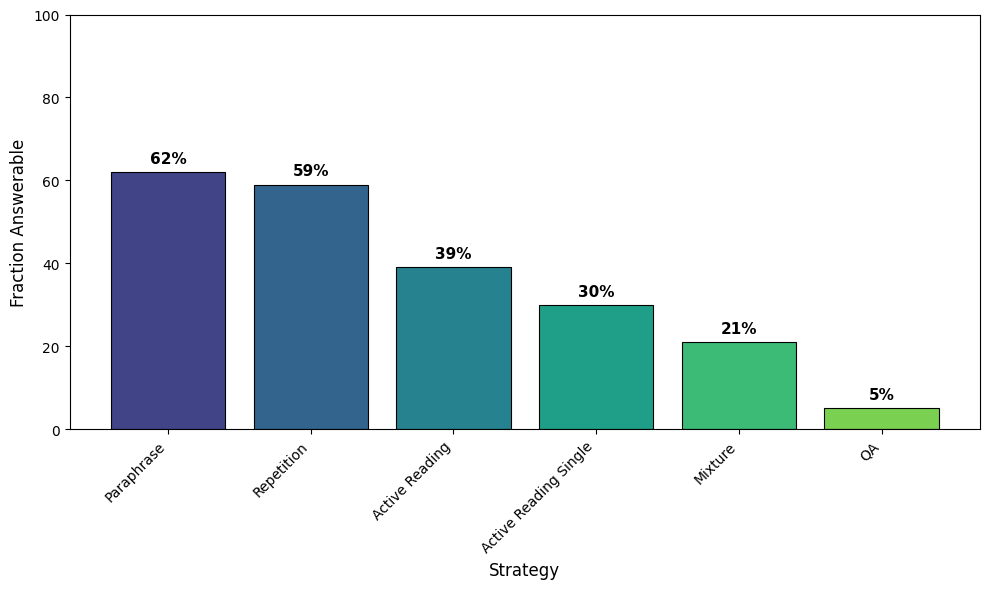

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Dataset results (sorted by match rate, descending)
datasets = [
    'Paraphrase',
    'Repetition',
    'Active Reading',
    'Active Reading Single',
    'Mixture',
    'QA'
]
matches = [62, 59, 39, 30, 21, 5]

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(datasets)))
bars = ax.bar(datasets, matches, color=colors, edgecolor='black', linewidth=0.8)

# Add value labels on bars
for bar, val in zip(bars, matches):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, 
            f'{val}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Styling
ax.set_ylabel('Fraction Answerable', fontsize=12)
ax.set_xlabel('Strategy', fontsize=12)
ax.set_ylim(0, 100)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()